In [ ]:
from google.colab import drive
import json
import pandas as pd

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
CSV_PATH = '/content/drive/MyDrive/dft-road-casualty-statistics-collision-2024.csv'

try:
    df = pd.read_csv(CSV_PATH, low_memory=False)
except FileNotFoundError:
    print("CSV not found. Creating synthetic demo dataset...")
    import numpy as np
    n = 5000
    df = pd.DataFrame({
        'collision_severity': np.random.choice([1, 2, 3], n, p=[0.01, 0.14, 0.85]),
        'speed_limit': np.random.choice([20, 30, 40, 50, 60, 70], n),
        'road_type': np.random.choice([1, 2, 3, 6, 7, 9, 12], n),
        'light_conditions': np.random.choice([1, 4, 5, 6, 7], n),
        'weather_conditions': np.random.choice([1, 2, 3, 4, 5, 6, 7, 8, 9], n),
        'road_surface_conditions': np.random.choice([1, 2, 3, 4, 5], n),
        'junction_detail': np.random.choice([0, 1, 2, 3, 5, 6], n),
        'junction_control': np.random.choice([-1, 0, 1, 2, 3, 4], n),
        'pedestrian_crossing': np.random.choice([0, 1, 2, 4, 5, 7, 8], n),
        'special_conditions_at_site': np.random.choice([0, 1, 2, 3, 4, 5, 6], n),
        'carriageway_hazards': np.random.choice([0, 1, 2, 3, 4, 5, 6, 7], n),
        'urban_or_rural_area': np.random.choice([1, 2, 3], n),
        'number_of_vehicles': np.random.randint(1, 6, n),
        'did_police_officer_attend_scene_of_accident': np.random.choice([1, 2, 3], n),
        'trunk_road_flag': np.random.choice([0, 2], n),
        'first_road_class': np.random.choice([1, 2, 3, 4, 5, 6], n),
        'day_of_week': np.random.randint(1, 8, n),
        'time': [f"{h:02d}:{m:02d}" for h, m in zip(
            np.random.randint(0, 24, n),
            np.random.choice([0, 15, 30, 45], n)
        )],
        'collision_year': np.random.choice([2019, 2020, 2021, 2022, 2023], n),
        'collision_index': range(n),
        'collision_ref_no': range(n),
        'lsoa_of_accident_location': [f"E0{np.random.randint(1000000,9999999)}" for _ in range(n)],
        'local_authority_district': np.random.randint(1, 200, n),
        'police_force': np.random.randint(1, 50, n),
        'longitude': np.random.uniform(-5, 2, n),
        'latitude': np.random.uniform(50, 58, n),
    })
    print(f"Synthetic dataset created: {df.shape[0]:,} rows x {df.shape[1]} columns")

STEP 1: Loading Data
Loaded dataset: 100,927 rows x 44 columns

STEP 2: Data Cleaning

STEP 3: Feature Engineering

STEP 4: Missing Value Handling and Encoding
Final shape after preprocessing: (100927, 28)

STEP 5: Train / Validation / Test Split
Number of features: 27
Target mapping: 0 = Fatal, 1 = Serious, 2 = Slight
Train shape: (72918, 27)
Validation shape: (12869, 27)
Test shape: (15140, 27)

STEP 6: Baseline XGBoost Training Without SMOTE
[0]	validation_0-mlogloss:0.61513
[50]	validation_0-mlogloss:0.57665
[100]	validation_0-mlogloss:0.57373
[150]	validation_0-mlogloss:0.57314
[181]	validation_0-mlogloss:0.57326

STEP 7: Baseline Evaluation
Baseline Accuracy         : 0.7515
Baseline Balanced Accuracy: 0.3359
Baseline Macro F1         : 0.2933
Baseline Weighted F1      : 0.6500

Baseline Classification Report:
              precision    recall  f1-score   support

       Fatal     0.0000    0.0000    0.0000       225
     Serious     0.4598    0.0113    0.0221      3535
      Sli

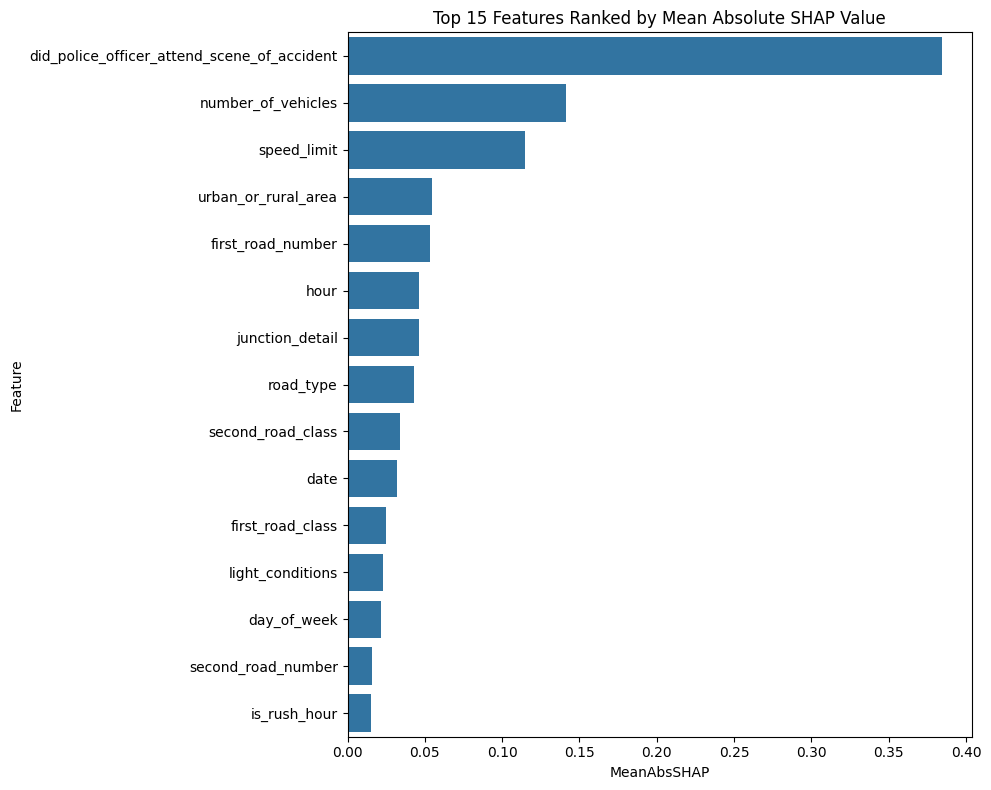

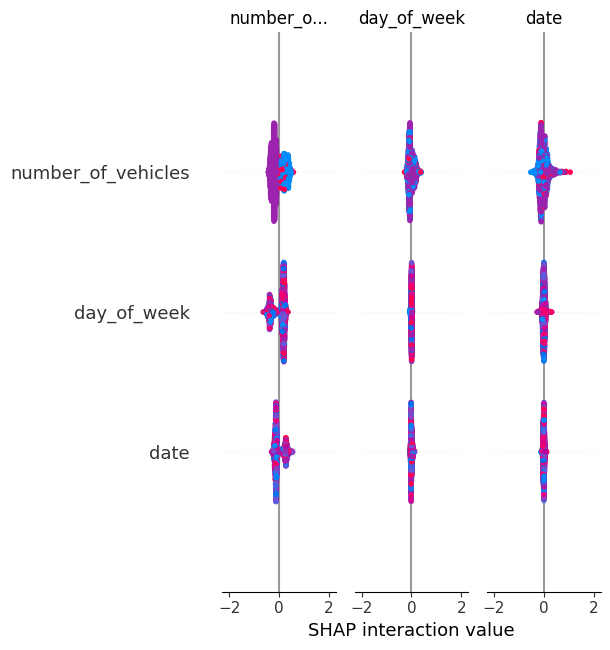


STEP 9: Selecting Important Features
Selected top 15 features:
['did_police_officer_attend_scene_of_accident', 'number_of_vehicles', 'speed_limit', 'urban_or_rural_area', 'first_road_number', 'hour', 'junction_detail', 'road_type', 'second_road_class', 'date', 'first_road_class', 'light_conditions', 'day_of_week', 'second_road_number', 'is_rush_hour']

STEP 10: Retraining Model with Selected Features
[0]	validation_0-mlogloss:0.61392
[50]	validation_0-mlogloss:0.57715
[100]	validation_0-mlogloss:0.57434
[150]	validation_0-mlogloss:0.57389
[193]	validation_0-mlogloss:0.57399

STEP 11: Final Evaluation After Feature Selection
Final Accuracy         : 0.7512
Final Balanced Accuracy: 0.3353
Final Macro F1         : 0.2922
Final Weighted F1      : 0.6491

Final Classification Report:
              precision    recall  f1-score   support

       Fatal     0.0000    0.0000    0.0000       225
     Serious     0.4250    0.0096    0.0188      3535
      Slight     0.7529    0.9964    0.8577   

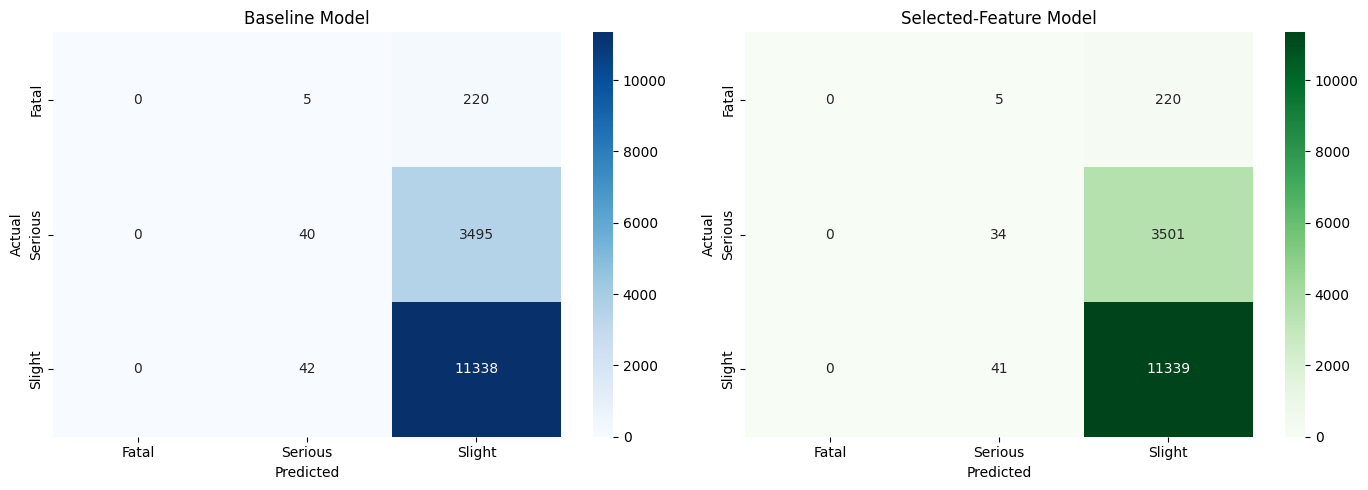


STEP 13: Comparison Table
                              Model  Accuracy  Balanced Accuracy  Macro F1  \
0                  Baseline XGBoost  0.751519           0.335875  0.293318   
1  XGBoost + SHAP Feature Selection  0.751189           0.335338  0.292175   

   Weighted F1  
0     0.649974  
1     0.649095  

STEP 14: Single Prediction Function

Example Prediction:
{'predicted_severity': 'Slight', 'probability_Fatal': 0.0332, 'probability_Serious': 0.258, 'probability_Slight': 0.7088}

Pipeline complete.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
CSV_PATH = '/content/drive/MyDrive/dft-road-casualty-statistics-collision-2024.csv'

print("=" * 70)
print("STEP 1: Loading Data")
print("=" * 70)

try:
    df = pd.read_csv(CSV_PATH, low_memory=False)
    print(f"Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
except FileNotFoundError:
    print("CSV not found. Creating synthetic demo dataset...")
    np.random.seed(42)
    n = 5000
    df = pd.DataFrame({
        'collision_severity': np.random.choice([1, 2, 3], n, p=[0.01, 0.14, 0.85]),
        'speed_limit': np.random.choice([20, 30, 40, 50, 60, 70], n),
        'road_type': np.random.choice([1, 2, 3, 6, 7, 9, 12], n),
        'light_conditions': np.random.choice([1, 4, 5, 6, 7], n),
        'weather_conditions': np.random.choice([1, 2, 3, 4, 5, 6, 7, 8, 9], n),
        'road_surface_conditions': np.random.choice([1, 2, 3, 4, 5], n),
        'junction_detail': np.random.choice([0, 1, 2, 3, 5, 6], n),
        'junction_control': np.random.choice([-1, 0, 1, 2, 3, 4], n),
        'pedestrian_crossing': np.random.choice([0, 1, 2, 4, 5, 7, 8], n),
        'special_conditions_at_site': np.random.choice([0, 1, 2, 3, 4, 5, 6], n),
        'carriageway_hazards': np.random.choice([0, 1, 2, 3, 4, 5, 6, 7], n),
        'urban_or_rural_area': np.random.choice([1, 2, 3], n),
        'number_of_vehicles': np.random.randint(1, 6, n),
        'did_police_officer_attend_scene_of_accident': np.random.choice([1, 2, 3], n),
        'trunk_road_flag': np.random.choice([0, 2], n),
        'first_road_class': np.random.choice([1, 2, 3, 4, 5, 6], n),
        'day_of_week': np.random.randint(1, 8, n),
        'time': [f"{h:02d}:{m:02d}" for h, m in zip(
            np.random.randint(0, 24, n),
            np.random.choice([0, 15, 30, 45], n)
        )],
        'collision_year': np.random.choice([2019, 2020, 2021, 2022, 2023], n),
        'collision_index': range(n),
        'collision_ref_no': range(n),
        'lsoa_of_accident_location': [f"E0{np.random.randint(1000000,9999999)}" for _ in range(n)],
        'local_authority_district': np.random.randint(1, 200, n),
        'police_force': np.random.randint(1, 50, n),
        'longitude': np.random.uniform(-5, 2, n),
        'latitude': np.random.uniform(50, 58, n),
    })
    print(f"Synthetic dataset created: {df.shape[0]:,} rows x {df.shape[1]} columns")

# ------------------------------------------------------------
# 2. DATA CLEANING
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 2: Data Cleaning")
print("=" * 70)

TARGET = "collision_severity"
assert TARGET in df.columns, f"Target column '{TARGET}' not found."

# Keep valid severity values
df = df[df[TARGET].isin([1, 2, 3])].copy()

# Drop leakage / IDs / very high-cardinality / post-event columns
DROP_COLS = [
    'collision_index',
    'collision_ref_no',
    'lsoa_of_accident_location',
    'local_authority_district',
    'local_authority_ons_district',
    'local_authority_highway',
    'local_authority_highway_current',
    'police_force',
    'longitude',
    'latitude',
    'location_easting_osgr',
    'location_northing_osgr',
    'junction_detail_historic',
    'pedestrian_crossing_human_control_historic',
    'pedestrian_crossing_physical_facilities_historic',
    'carriageway_hazards_historic',
    'enhanced_severity_collision',
    'collision_injury_based',
    'collision_adjusted_severity_serious',
    'collision_adjusted_severity_slight',
    'number_of_casualties'
]

existing_drops = [c for c in DROP_COLS if c in df.columns]
df.drop(columns=existing_drops, inplace=True)

# Replace coded missing values with NaN
MISSING_CODES = [-1, 9, 99, 999, -99]
df.replace(MISSING_CODES, np.nan, inplace=True)

# Convert time into hour
if "time" in df.columns:
    df["hour"] = pd.to_datetime(df["time"], format="%H:%M", errors="coerce").dt.hour
    df.drop(columns=["time"], inplace=True)

# ------------------------------------------------------------
# 3. FEATURE ENGINEERING
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 3: Feature Engineering")
print("=" * 70)

if "hour" in df.columns:
    df["is_rush_hour"] = df["hour"].isin(list(range(7, 10)) + list(range(16, 20))).astype(int)
    df["is_night"] = df["hour"].isin(list(range(22, 24)) + list(range(0, 6))).astype(int)

if "day_of_week" in df.columns:
    df["is_weekend"] = df["day_of_week"].isin([1, 7]).astype(int)

if "light_conditions" in df.columns:
    df["is_dark"] = df["light_conditions"].isin([4, 5, 6, 7]).astype(int)

if "road_surface_conditions" in df.columns:
    df["is_wet_road"] = df["road_surface_conditions"].isin([2, 3, 4]).astype(int)

if "weather_conditions" in df.columns:
    df["is_bad_weather"] = df["weather_conditions"].isin([2, 3, 4, 5, 6, 7, 8]).astype(int)

# Drop collision_year as feature
if "collision_year" in df.columns:
    df.drop(columns=["collision_year"], inplace=True)

# ------------------------------------------------------------
# 4. IMPUTATION + ENCODING
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 4: Missing Value Handling and Encoding")
print("=" * 70)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Fill numeric
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical
for col in categorical_cols:
    mode_val = df[col].mode(dropna=True)
    df[col] = df[col].fillna(mode_val.iloc[0] if len(mode_val) > 0 else "Unknown")

# Encode object columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Final shape after preprocessing:", df.shape)

# ------------------------------------------------------------
# 5. TRAIN / VALIDATION / TEST SPLIT
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 5: Train / Validation / Test Split")
print("=" * 70)

FEATURE_COLS = [c for c in df.columns if c != TARGET]

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy() - 1   # map 1,2,3 -> 0,1,2

print("Number of features:", len(FEATURE_COLS))
print("Target mapping: 0 = Fatal, 1 = Serious, 2 = Slight")

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# ------------------------------------------------------------
# 6. BASELINE MODEL WITHOUT SMOTE
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 6: Baseline XGBoost Training Without SMOTE")
print("=" * 70)

baseline_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    gamma=0.2,
    random_state=42,
    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=30
)

baseline_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# ------------------------------------------------------------
# 7. BASELINE EVALUATION
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 7: Baseline Evaluation")
print("=" * 70)

y_pred_base = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_base)
baseline_bal_acc = balanced_accuracy_score(y_test, y_pred_base)
baseline_macro_f1 = f1_score(y_test, y_pred_base, average="macro")
baseline_weighted_f1 = f1_score(y_test, y_pred_base, average="weighted")

print(f"Baseline Accuracy         : {baseline_acc:.4f}")
print(f"Baseline Balanced Accuracy: {baseline_bal_acc:.4f}")
print(f"Baseline Macro F1         : {baseline_macro_f1:.4f}")
print(f"Baseline Weighted F1      : {baseline_weighted_f1:.4f}")

print("\nBaseline Classification Report:")
print(classification_report(
    y_test, y_pred_base,
    target_names=["Fatal", "Serious", "Slight"],
    digits=4
))

# ------------------------------------------------------------
# 8. EXPLAINABLE AI USING SHAP
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 8: Explainable AI with SHAP")
print("=" * 70)

# Use a subset for SHAP if dataset is large
sample_size = min(2000, len(X_train))
X_shap = X_train.sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(baseline_model)
shap_values = explainer.shap_values(X_shap)

# Multi-class SHAP handling
# shap_values may come as:
#   - list of arrays [class0, class1, class2]
#   - or ndarray with class dimension
if isinstance(shap_values, list):
    # each array shape: (n_samples, n_features)
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    # try to handle ndarray shapes robustly
    shap_arr = np.array(shap_values)
    if shap_arr.ndim == 3:
        # likely (n_samples, n_features, n_classes) or (n_classes, n_samples, n_features)
        if shap_arr.shape[0] == 3:
            mean_abs_shap = np.mean(np.abs(shap_arr), axis=(0, 1))
        elif shap_arr.shape[-1] == 3:
            mean_abs_shap = np.mean(np.abs(shap_arr), axis=(0, 2))
        else:
            mean_abs_shap = np.mean(np.abs(shap_arr), axis=0).mean(axis=0)
    else:
        mean_abs_shap = np.abs(shap_arr).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values(by="MeanAbsSHAP", ascending=False)

print("\nTop 20 SHAP-ranked features:")
print(shap_importance_df.head(20))

# Plot SHAP ranking
plt.figure(figsize=(10, 8))
sns.barplot(
    data=shap_importance_df.head(15),
    x="MeanAbsSHAP",
    y="Feature"
)
plt.title("Top 15 Features Ranked by Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

# Optional SHAP summary plot
try:
    if isinstance(shap_values, list):
        # use first class just for display, or aggregate visualization separately
        shap.summary_plot(shap_values[0], X_shap, show=False)
    else:
        shap.summary_plot(shap_values, X_shap, show=False)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("SHAP summary plot skipped due to version/shape issue:", str(e))

# ------------------------------------------------------------
# 9. SELECT IMPORTANT FEATURES
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 9: Selecting Important Features")
print("=" * 70)

# Strategy: keep top 15 features or top 50%, whichever is smaller
TOP_K = min(15, len(shap_importance_df))
selected_features = shap_importance_df.head(TOP_K)["Feature"].tolist()

print(f"Selected top {TOP_K} features:")
print(selected_features)

X_train_sel = X_train[selected_features].copy()
X_val_sel   = X_val[selected_features].copy()
X_test_sel  = X_test[selected_features].copy()

# ------------------------------------------------------------
# 10. RETRAIN MODEL USING IMPORTANT FEATURES
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 10: Retraining Model with Selected Features")
print("=" * 70)

final_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=2.0,
    gamma=0.2,
    random_state=42,
    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=30
)

final_model.fit(
    X_train_sel, y_train,
    eval_set=[(X_val_sel, y_val)],
    verbose=50
)

# ------------------------------------------------------------
# 11. FINAL EVALUATION
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 11: Final Evaluation After Feature Selection")
print("=" * 70)

y_pred_final = final_model.predict(X_test_sel)

final_acc = accuracy_score(y_test, y_pred_final)
final_bal_acc = balanced_accuracy_score(y_test, y_pred_final)
final_macro_f1 = f1_score(y_test, y_pred_final, average="macro")
final_weighted_f1 = f1_score(y_test, y_pred_final, average="weighted")

print(f"Final Accuracy         : {final_acc:.4f}")
print(f"Final Balanced Accuracy: {final_bal_acc:.4f}")
print(f"Final Macro F1         : {final_macro_f1:.4f}")
print(f"Final Weighted F1      : {final_weighted_f1:.4f}")

print("\nFinal Classification Report:")
print(classification_report(
    y_test, y_pred_final,
    target_names=["Fatal", "Serious", "Slight"],
    digits=4
))

# ------------------------------------------------------------
# 12. CONFUSION MATRICES
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 12: Confusion Matrices")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(
    cm_base, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Fatal", "Serious", "Slight"],
    yticklabels=["Fatal", "Serious", "Slight"],
    ax=axes[0]
)
axes[0].set_title("Baseline Model")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(
    cm_final, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Fatal", "Serious", "Slight"],
    yticklabels=["Fatal", "Serious", "Slight"],
    ax=axes[1]
)
axes[1].set_title("Selected-Feature Model")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. PERFORMANCE COMPARISON
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 13: Comparison Table")
print("=" * 70)

comparison_df = pd.DataFrame({
    "Model": ["Baseline XGBoost", "XGBoost + SHAP Feature Selection"],
    "Accuracy": [baseline_acc, final_acc],
    "Balanced Accuracy": [baseline_bal_acc, final_bal_acc],
    "Macro F1": [baseline_macro_f1, final_macro_f1],
    "Weighted F1": [baseline_weighted_f1, final_weighted_f1]
})

print(comparison_df)

# ------------------------------------------------------------
# 14. INFERENCE FUNCTION
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 14: Single Prediction Function")
print("=" * 70)

label_map = {0: "Fatal", 1: "Serious", 2: "Slight"}

def predict_severity_selected_features(raw_features: dict):
    sample = pd.DataFrame([raw_features])

    # Add missing columns from original feature space
    for col in FEATURE_COLS:
        if col not in sample.columns:
            sample[col] = 0

    # Encode categorical columns if needed
    for col in categorical_cols:
        if col in sample.columns:
            sample[col] = sample[col].astype(str)
            known_classes = set(label_encoders[col].classes_)
            default_class = label_encoders[col].classes_[0]
            sample[col] = sample[col].apply(lambda x: x if x in known_classes else default_class)
            sample[col] = label_encoders[col].transform(sample[col])

    # Keep only selected features
    sample = sample[selected_features]

    probs = final_model.predict_proba(sample)[0]
    pred = int(np.argmax(probs))

    return {
        "predicted_severity": label_map[pred],
        "probability_Fatal": round(float(probs[0]), 4),
        "probability_Serious": round(float(probs[1]), 4),
        "probability_Slight": round(float(probs[2]), 4)
    }

# Example prediction
example = {
    'speed_limit': 60,
    'road_type': 2,
    'light_conditions': 5,
    'weather_conditions': 2,
    'road_surface_conditions': 2,
    'junction_detail': 0,
    'junction_control': 0,
    'pedestrian_crossing': 0,
    'special_conditions_at_site': 0,
    'carriageway_hazards': 0,
    'urban_or_rural_area': 2,
    'number_of_vehicles': 2,
    'did_police_officer_attend_scene_of_accident': 1,
    'trunk_road_flag': 2,
    'first_road_class': 2,
    'day_of_week': 7,
    'hour': 23,
    'is_rush_hour': 0,
    'is_night': 1,
    'is_weekend': 1,
    'is_dark': 1,
    'is_wet_road': 1,
    'is_bad_weather': 1,
}

result = predict_severity_selected_features(example)

print("\nExample Prediction:")
print(result)

print("\nPipeline complete.")